<a href="https://colab.research.google.com/github/Siddhant082006/CIFAR-10-Image-classification-using-CNN/blob/main/cifar10_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os, time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None (using CPU)"}')

Using device: cuda
GPU: Tesla T4


## 2. Preparing Dataset



In [ ]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

CLASSES = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

# Training transforms — with augmentation
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# Test transforms — no augmentation, just normalize
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# Download dataset
full_train = datasets.CIFAR10(root='./data', train=True,  download=True, transform=train_transform)
test_set   = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

# Train / Val split (90% / 10%)
val_size   = int(0.1 * len(full_train))   # 5,000
train_size = len(full_train) - val_size   # 45,000
train_set, val_set = random_split(full_train, [train_size, val_size],
                                  generator=torch.Generator().manual_seed(42))

BATCH_SIZE = 64
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {train_size:,} | Val: {val_size:,} | Test: {len(test_set):,}')

100%|██████████| 170M/170M [50:41<00:00, 56.1kB/s]


Train: 45,000 | Val: 5,000 | Test: 10,000


## 3. Visualize Sample Images

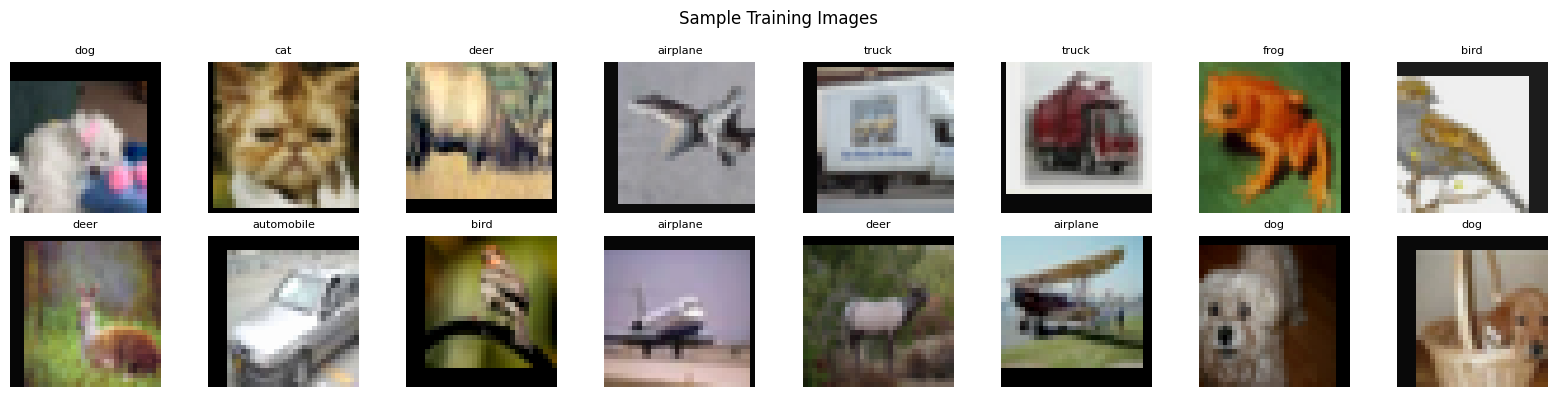

In [ ]:
# Peek at some training images
images, labels = next(iter(train_loader))

mean = torch.tensor(CIFAR10_MEAN).view(3,1,1)
std  = torch.tensor(CIFAR10_STD).view(3,1,1)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flatten()):
    img = (images[i] * std + mean).clamp(0,1).permute(1,2,0).numpy()
    ax.imshow(img)
    ax.set_title(CLASSES[labels[i]], fontsize=8)
    ax.axis('off')
plt.suptitle('Sample Training Images', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
class ImageClassifierCNN(nn.Module):
    """
    CNN Architecture:
      Conv Block 1: Conv(3->32) -> BN -> ReLU -> Conv(32->32) -> BN -> ReLU -> MaxPool -> Dropout
      Conv Block 2: Conv(32->64) -> BN -> ReLU -> Conv(64->64) -> BN -> ReLU -> MaxPool -> Dropout
      Classifier  : Flatten -> FC(4096->256) -> ReLU -> Dropout -> FC(256->10)
    """
    def __init__(self, num_classes=10, dropout_rate=0.25):
        super().__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),          # 32x32 -> 16x16
            nn.Dropout2d(dropout_rate),
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),          # 16x16 -> 8x8
            nn.Dropout2d(dropout_rate),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.classifier(x)
        return x


model = ImageClassifierCNN().to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTotal trainable parameters: {total_params:,}')

ImageClassifierCNN(
  (conv_block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel

## 4. CNN Model

## 5. Training Setup

In [ ]:
NUM_EPOCHS = 30

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print('Loss     :', criterion)
print('Optimizer:', optimizer.__class__.__name__)
print('Scheduler:', scheduler.__class__.__name__)
print('Epochs   :', NUM_EPOCHS)

Loss     : CrossEntropyLoss()
Optimizer: Adam
Scheduler: CosineAnnealingLR
Epochs   : 30


## 6. Train the Model

In [ ]:
os.makedirs('./results', exist_ok=True)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0

print(f'Training on {device} for {NUM_EPOCHS} epochs')
print('─' * 70)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    # ── Train ──
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss    += loss.item() * images.size(0)
        train_correct += outputs.argmax(1).eq(labels).sum().item()
        train_total   += images.size(0)

    # ── Validate ──
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss    += loss.item() * images.size(0)
            val_correct += outputs.argmax(1).eq(labels).sum().item()
            val_total   += images.size(0)

    scheduler.step()

    t_loss = train_loss / train_total
    t_acc  = train_correct / train_total
    v_loss = val_loss / val_total
    v_acc  = val_correct / val_total

    history['train_loss'].append(t_loss)
    history['train_acc'].append(t_acc)
    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc)

    elapsed = time.time() - t0
    print(f'Epoch [{epoch:>2}/{NUM_EPOCHS}] '
          f'| Train Loss: {t_loss:.4f}  Acc: {t_acc:.4f} '
          f'| Val Loss: {v_loss:.4f}  Acc: {v_acc:.4f} '
          f'| {elapsed:.1f}s')

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(model.state_dict(), './results/best_model.pth')
        print(f'  ✓ Best model saved  (val acc: {best_val_acc:.4f})')

print(f'\nTraining complete! Best val accuracy: {best_val_acc:.4f}')

Training on cuda for 30 epochs
──────────────────────────────────────────────────────────────────────
Epoch [ 1/30] | Train Loss: 1.8830  Acc: 0.2951 | Val Loss: 1.5711  Acc: 0.4122 | 34.7s
  ✓ Best model saved  (val acc: 0.4122)
Epoch [ 2/30] | Train Loss: 1.6809  Acc: 0.3675 | Val Loss: 1.4917  Acc: 0.4654 | 32.7s
  ✓ Best model saved  (val acc: 0.4654)
Epoch [ 3/30] | Train Loss: 1.5648  Acc: 0.4217 | Val Loss: 1.3064  Acc: 0.5156 | 34.1s
  ✓ Best model saved  (val acc: 0.5156)
Epoch [ 4/30] | Train Loss: 1.4773  Acc: 0.4579 | Val Loss: 1.2349  Acc: 0.5486 | 32.8s
  ✓ Best model saved  (val acc: 0.5486)
Epoch [ 5/30] | Train Loss: 1.4078  Acc: 0.4884 | Val Loss: 1.1423  Acc: 0.5938 | 33.0s
  ✓ Best model saved  (val acc: 0.5938)
Epoch [ 6/30] | Train Loss: 1.3630  Acc: 0.5058 | Val Loss: 1.1084  Acc: 0.6020 | 32.5s
  ✓ Best model saved  (val acc: 0.6020)
Epoch [ 7/30] | Train Loss: 1.3112  Acc: 0.5286 | Val Loss: 1.0488  Acc: 0.6110 | 32.7s
  ✓ Best model saved  (val acc: 0.6110)
Ep

## 7. Plot Training Curves

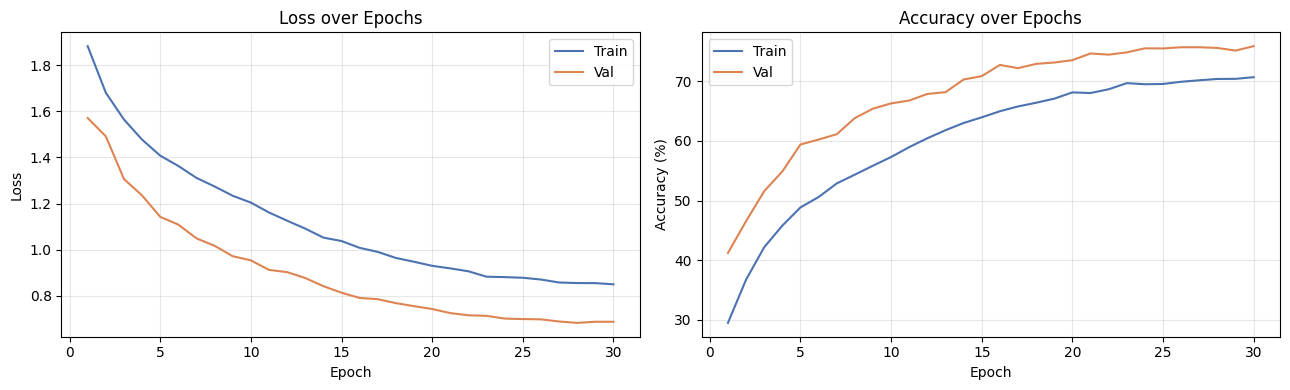

In [ ]:
epochs = range(1, NUM_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(epochs, history['train_loss'], label='Train', color='#4C72B0')
ax1.plot(epochs, history['val_loss'],   label='Val',   color='#DD8452')
ax1.set_title('Loss over Epochs'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, [a*100 for a in history['train_acc']], label='Train', color='#4C72B0')
ax2.plot(epochs, [a*100 for a in history['val_acc']],   label='Val',   color='#DD8452')
ax2.set_title('Accuracy over Epochs'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./results/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Test Set Evaluation

In [ ]:
# Load best model
model.load_state_dict(torch.load('./results/best_model.pth', map_location=device))
model.eval()

test_loss, test_correct, test_total = 0.0, 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss    += loss.item() * images.size(0)
        test_correct += outputs.argmax(1).eq(labels).sum().item()
        test_total   += images.size(0)

print('─' * 35)
print(f'Test Loss    : {test_loss/test_total:.4f}')
print(f'Test Accuracy: {test_correct/test_total*100:.2f}%')
print('─' * 35)

───────────────────────────────────
Test Loss    : 0.6305
Test Accuracy: 77.83%
───────────────────────────────────


## 9. Sample Predictions

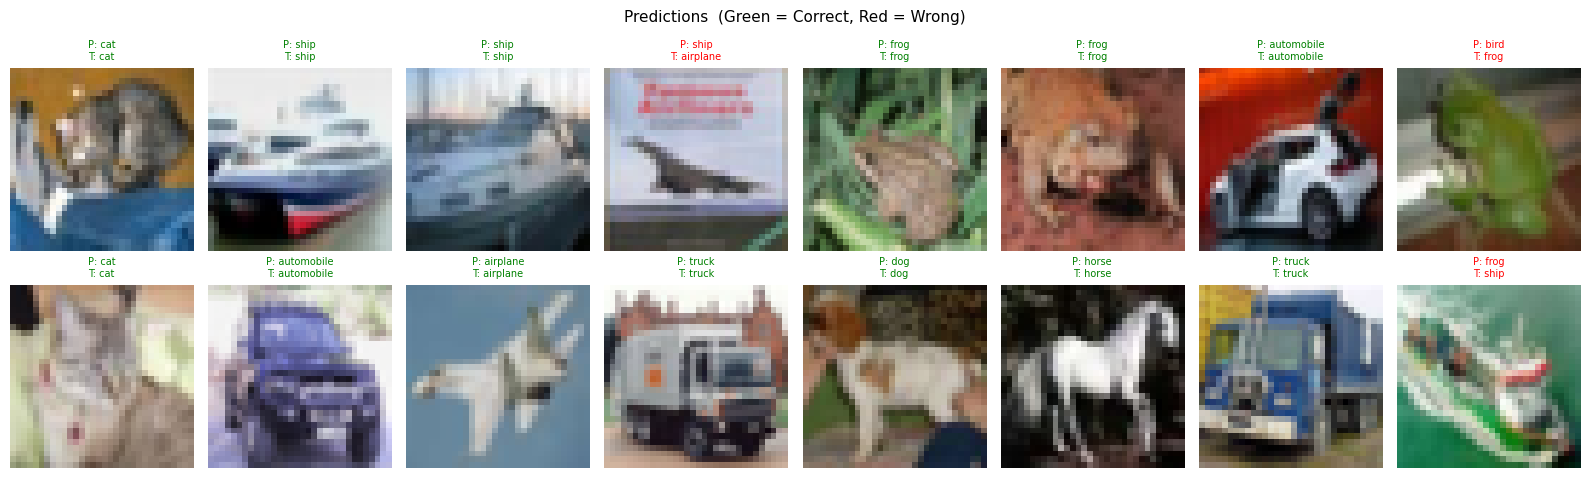

In [ ]:
mean_t = torch.tensor(CIFAR10_MEAN).view(3,1,1)
std_t  = torch.tensor(CIFAR10_STD).view(3,1,1)

images, labels = next(iter(test_loader))
with torch.no_grad():
    preds = model(images.to(device)).argmax(1).cpu()

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i, ax in enumerate(axes.flatten()):
    img = (images[i] * std_t + mean_t).clamp(0,1).permute(1,2,0).numpy()
    correct = preds[i] == labels[i]
    ax.imshow(img)
    ax.set_title(f'P: {CLASSES[preds[i]]}\nT: {CLASSES[labels[i]]}',
                 color='green' if correct else 'red', fontsize=7)
    ax.axis('off')

plt.suptitle('Predictions  (Green = Correct, Red = Wrong)', fontsize=11)
plt.tight_layout()
plt.savefig('./results/sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Confusion Matrix

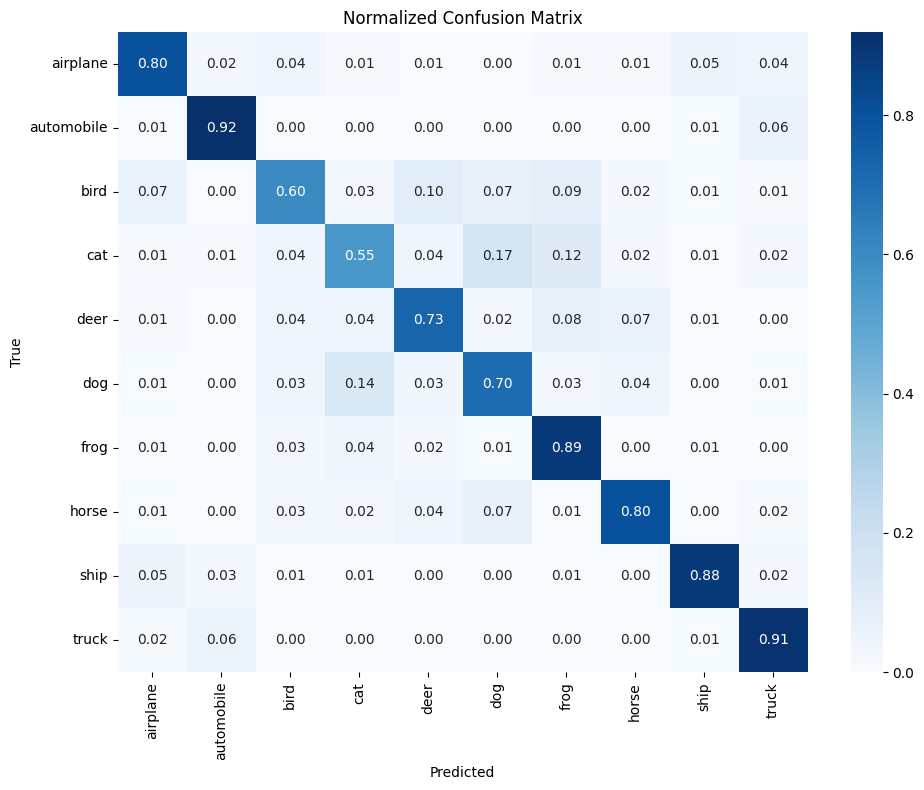

In [ ]:
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        preds = model(images.to(device)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds, normalize='true')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Normalized Confusion Matrix')
plt.tight_layout()
plt.savefig('./results/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()